In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder,FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,BaggingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import joblib


In [3]:
df=pd.read_csv('../Student Social Media And Mental Health Impact.csv')

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.shape

(5000, 13)

In [6]:
df.columns


Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [8]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df=df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
num_cols=df.select_dtypes(include=np.number).columns.tolist()
cat_cols=df.select_dtypes(include='object').columns.tolist()

C:\Users\thulu\AppData\Local\Temp\ipykernel_9000\2076864099.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include='object').columns.tolist()


In [13]:
num_cols

['Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score']

In [14]:
cat_cols

['Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Stress_Level']

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4998.0,20.822129,1.736774,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,4998.0,5.078491,1.654097,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,4998.0,171.455582,42.859829,62.0,140.0,171.0,204.0,273.0
Study_Hours,4998.0,3.008403,1.636831,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,4998.0,1.750760,0.668406,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,4998.0,6.634654,1.221561,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,4998.0,6.231152,1.278476,3.6,5.1,6.1,7.1,9.4


In [16]:
# Physical activity hours is negative hence its a data entry error

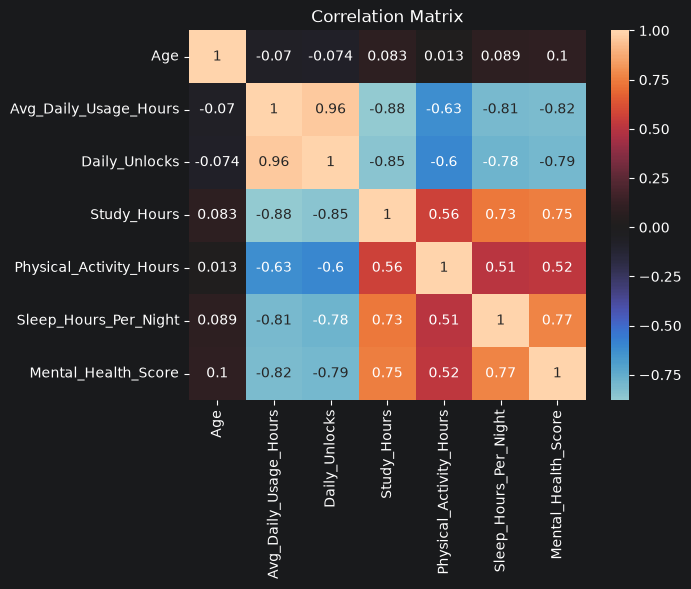

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True,center=0)
plt.title('Correlation Matrix')
plt.show()

In [18]:
# Almost all features show strong correlation with the target col
# Features are also strongly correlated among themselves

In [19]:
print(len(num_cols))
print(len(cat_cols))

7
6


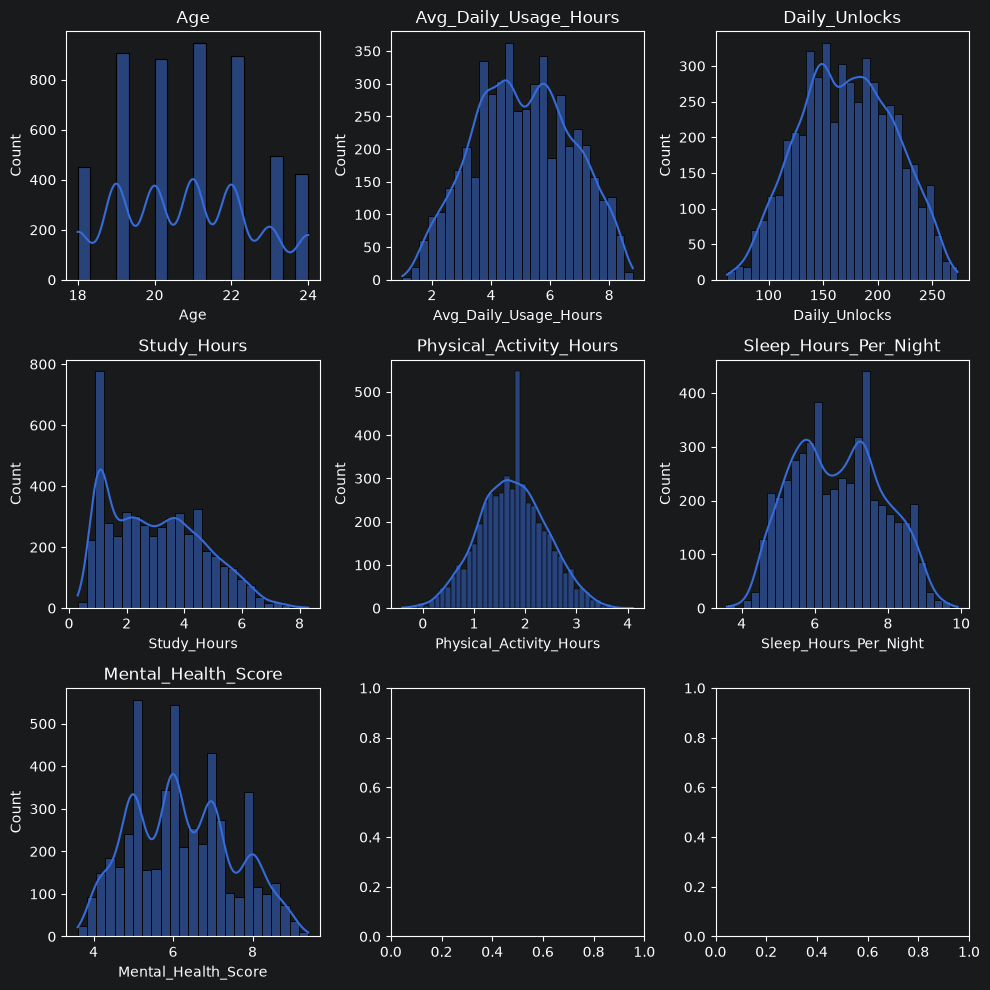

In [20]:
fig,axes=plt.subplots(3,3,figsize=(10,10))
axes=axes.flatten()

for idx,col in enumerate(num_cols):
    sns.histplot(df[col],kde=True,ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()


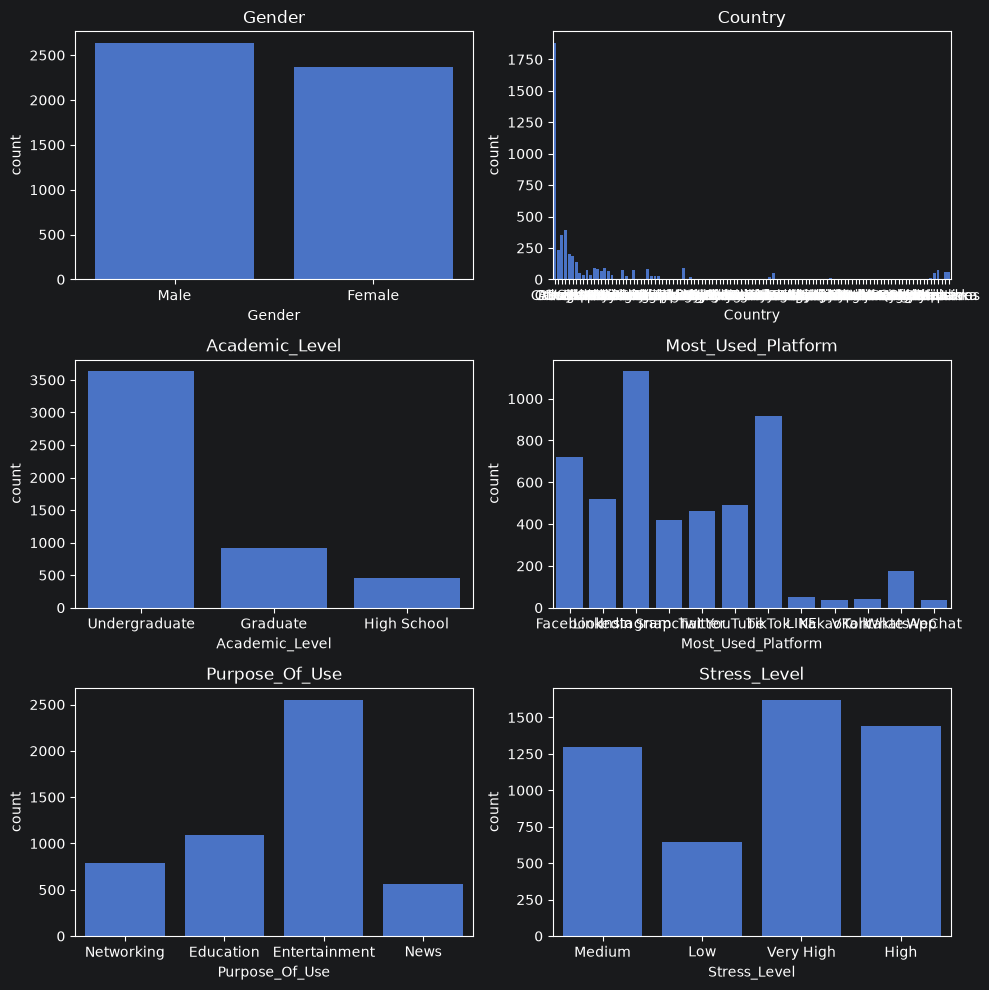

In [21]:
fig,axes=plt.subplots(3,2,figsize=(10,10))
axes=axes.flatten()

for idx,col in enumerate(cat_cols):
    sns.countplot(data=df,x=col,ax=axes[idx])
    axes[idx].set_title(col)
plt.tight_layout()
plt.show()

In [22]:
df[num_cols].corr(numeric_only=True)['Mental_Health_Score'].sort_values(ascending=False)

Mental_Health_Score        1.000000
Sleep_Hours_Per_Night      0.766462
Study_Hours                0.752483
Physical_Activity_Hours    0.521591
Age                        0.100464
Daily_Unlocks             -0.790830
Avg_Daily_Usage_Hours     -0.816485
Name: Mental_Health_Score, dtype: float64

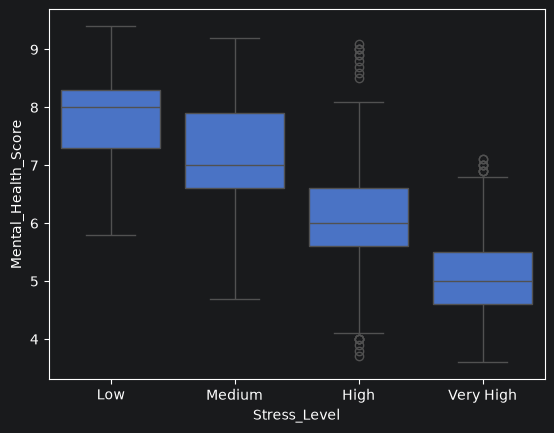

In [23]:
 order=['Low','Medium','High','Very High']
 sns.boxplot(x=df['Stress_Level'],y=df['Mental_Health_Score'],order=order)
 plt.show()

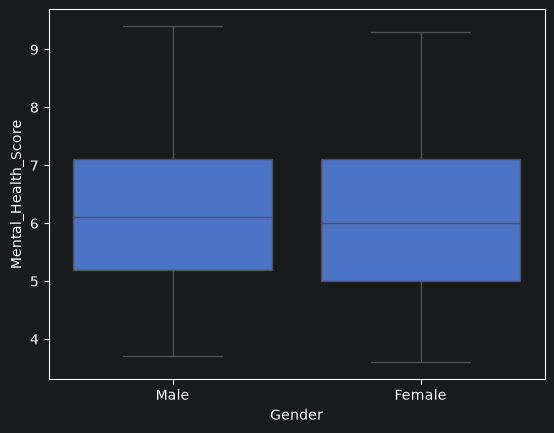

In [24]:
 sns.boxplot(x=df['Gender'],y=df['Mental_Health_Score'])
 plt.show()

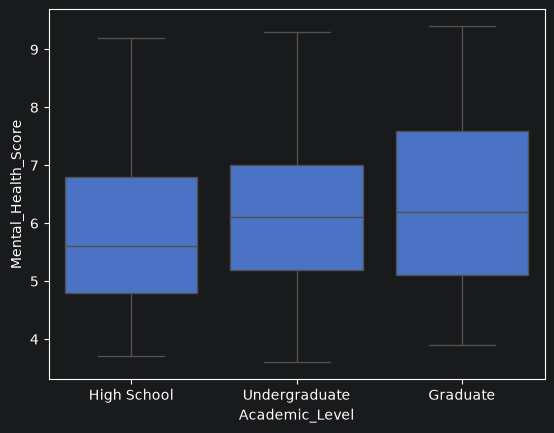

In [25]:
 order=['High School','Undergraduate','Graduate']
 sns.boxplot(x=df['Academic_Level'],y=df['Mental_Health_Score'],order=order)
 plt.show()

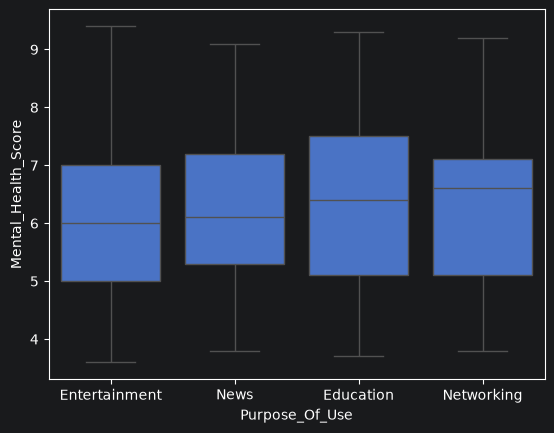

In [26]:
 order=['Entertainment','News','Education','Networking']
 sns.boxplot(x=df['Purpose_Of_Use'],y=df['Mental_Health_Score'],order=order)
 plt.show()

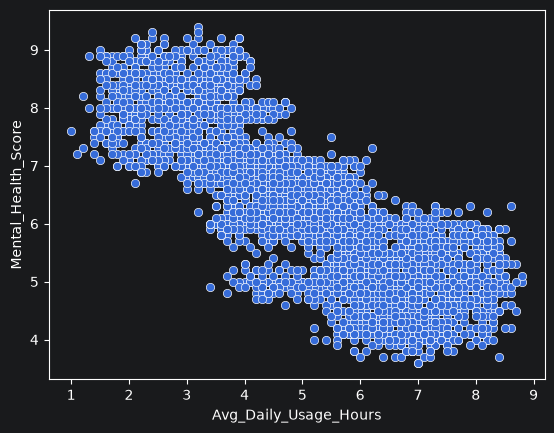

In [27]:
sns.scatterplot(data=df,x=df['Avg_Daily_Usage_Hours'],y=df['Mental_Health_Score'])
plt.show()

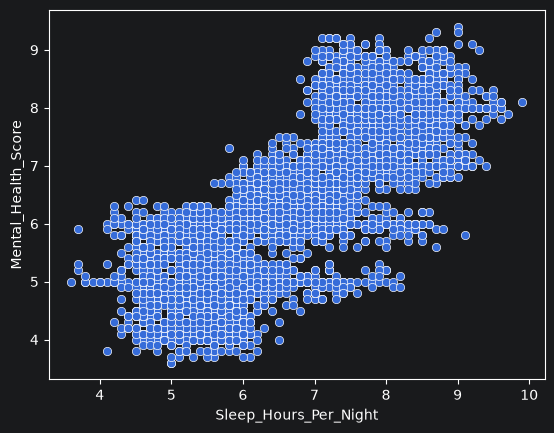

In [28]:
sns.scatterplot(data=df,x=df['Sleep_Hours_Per_Night'],y=df['Mental_Health_Score'])
plt.show()

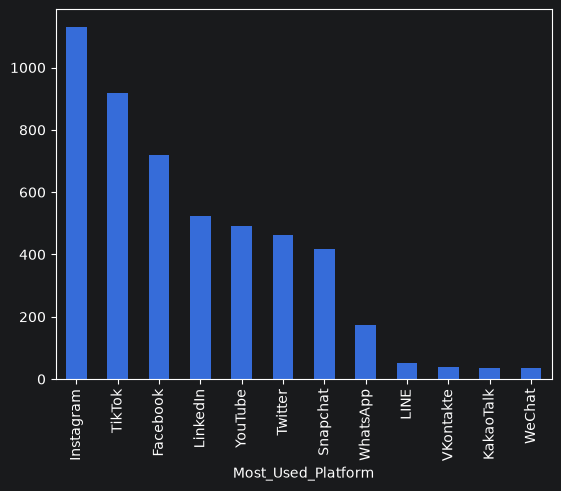

In [29]:
df['Most_Used_Platform'].value_counts().plot(kind='bar')

plt.show()

Check Outliers

In [30]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)

print(outliers.sum())



Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [31]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [32]:
df['Physical_Activity_Hours'].describe()

count    4998.000000
mean        1.751160
std         0.667282
min         0.000000
25%         1.300000
50%         1.700000
75%         2.200000
max         4.100000
Name: Physical_Activity_Hours, dtype: float64

In [33]:
df[num_cols].skew()

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [34]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [35]:
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [36]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [37]:
df['Country']=df['Country'].apply(group_countries)

In [38]:
df['Country'].value_counts()

Country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [39]:
df['Country'].nunique()

10

In [40]:
skewed_col=['Study_Hours']
other_numeric_cols=['Age',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night']

ordinal_col=['Stress_Level']
ohe_cols=['Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use']


In [41]:
X=df.drop('Mental_Health_Score',axis=1)
y=df['Mental_Health_Score']

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=0)

In [43]:
X.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High


In [44]:
y.head()

0    6.8
1    7.6
2    7.0
3    5.3
4    4.4
Name: Mental_Health_Score, dtype: float64

In [45]:
skew_pipeline=Pipeline(steps=[('log_trans',FunctionTransformer(np.log1p)),('scale',StandardScaler())])

plain_numeric_pipeline=Pipeline(steps=[('scale',StandardScaler())])

ordinal_pipeline=Pipeline(steps=[('ordinal',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))])

ohe_pipeline=Pipeline(steps=[('ohe',OneHotEncoder(handle_unknown='ignore',sparse_output=False,drop='first'))])

In [46]:
preprocessor=ColumnTransformer(transformers=[
    ('trf1',skew_pipeline,skewed_col),
    ('trf2',plain_numeric_pipeline,other_numeric_cols),
    ('trf3',ordinal_pipeline,ordinal_col),
    ('trf4',ohe_pipeline,ohe_cols)
],remainder='passthrough')

In [47]:
# training our base model
lr_pipe=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('lr',LinearRegression())
])

In [48]:
X_train.duplicated().sum()

np.int64(2)

In [49]:
X_train.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level'],
      dtype='str')

In [50]:
lr_pipe.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('trf2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

In [51]:
y_pred = lr_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R²:", r2)
print("MSE:", mse)
print("RMSE:", rmse)

R²: 0.7339154279827684
MSE: 0.44319139710874866
RMSE: 0.6657262178318867


In [52]:
rf_pipe=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('rf',RandomForestRegressor(random_state=0))
])

In [53]:
rf_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('trf2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

In [54]:
y_pred_train = rf_pipe.predict(X_train)
y_pred_test = rf_pipe.predict(X_test)

r2_train = r2_score(y_train, y_pred_train)
r2_test=r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R² Train:", r2_train)
print("R² Test:", r2_test)
print("MSE:", mse)
print("RMSE:", rmse)

R² Train: 0.983062130450378
R² Test: 0.8769073453686667
MSE: 0.44319139710874866
RMSE: 0.6657262178318867


In [55]:
# Model Evaluation
models={
    'knn':Pipeline(
        steps=[
            ('preprocessor',preprocessor),
            ('model1',KNeighborsRegressor())]),
    'svm':Pipeline(
        steps=[
            ('preprocessor',preprocessor),
            ('model2',SVR())]),
    'dt':Pipeline(
        steps=[
            ('preprocessor',preprocessor),
            ('model3',DecisionTreeRegressor(random_state=0))]),
    'rf':Pipeline(
        steps=[
            ('preprocessor',preprocessor),
            ('model4',RandomForestRegressor(random_state=0))]),
    'gb':Pipeline(
        steps=[
            ('preprocessor',preprocessor),
            ('model5',GradientBoostingRegressor(random_state=0))]),
    'bg':Pipeline(
        steps=[
            ('preprocessor',preprocessor),
            ('model6',BaggingRegressor(random_state=0))])
}

In [56]:
scoring={
    'r2':'r2',
    'mse':'neg_mean_squared_error',
    'mae':'neg_mean_absolute_error'
}

In [57]:
cv=KFold(n_splits=5,shuffle=True,random_state=0)

In [58]:
final_score=[]

for name,model in models.items():
    scores=cross_validate(model,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    final_score.append({
        'Model':name,
        'r2_score':scores['test_r2'].mean(),
        'MSE':-scores['test_mse'].mean(),
        'MAE':-scores['test_mae'].mean()
    })


In [59]:
pd.DataFrame(final_score).sort_values('r2_score',ascending=False).reset_index(drop=True)

,Model,r2_score,MSE,MAE
0,rf,0.863930,0.220642,0.349218
1,bg,0.850122,0.243138,0.367616
2,knn,0.820831,0.290598,0.396095
3,svm,0.794065,0.334000,0.434852
4,gb,0.792315,0.336758,0.451388
5,dt,0.741695,0.418961,0.426515


In [60]:
rf_param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 10, 20],
    "rf__min_samples_split": [2, 3,5,7],
    "rf__min_samples_leaf": [1, 2,3,4,5],
    "rf__max_features": ["sqrt", "log2"]
}

In [61]:
grid=GridSearchCV(estimator=rf_pipe,param_grid=rf_param_grid,cv=cv,scoring='r2',n_jobs=-1)

In [62]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'rf__max_depth': [None, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2, ...], 'rf__min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versio

In [63]:
print('best parameters ',grid.best_params_)
print('Best Score ',grid.best_score_)

best parameters  {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
Best Score  0.8803816060444184


In [64]:
# final Model
grid.best_estimator_.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Age','Gender','Country',...,'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Stress_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('trf1', ...), ('trf2', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed th

In [65]:
joblib.dump(grid.best_estimator_, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [70]:
df['Stress_Level'].unique().tolist()

['Medium', 'Low', 'Very High', 'High']